# Load Pickle SOM
___

In [19]:
#Library Import
import numpy as np
from numba import jit
from PIL import Image
import os
import matplotlib.pyplot as plt
import pickle

#### Code

In [2]:
class NumbaSOM:
    def __init__(self, x, y, input_len, learning_rate=0.5, sigma=None):
        """
        Initialize the SOM.
        :param x: Number of rows in the SOM grid.
        :param y: Number of columns in the SOM grid.
        :param input_len: Length of the input vector.
        :param learning_rate: Initial learning rate.
        :param sigma: Initial neighborhood radius.
        """
        self.x = x
        self.y = y
        self.input_len = input_len
        self.learning_rate = learning_rate
        self.sigma = sigma if sigma else max(x, y) / 2.0
        self.weights = np.random.random((x, y, input_len))
        self.iteration = 0
    
    @staticmethod
    @jit(nopython=True)
    def euclidean_distance(vec1, vec2):
        """Calculate the Euclidean distance."""
        return np.sqrt(np.sum((vec1 - vec2) ** 2))
    
    def find_bmu(self, input_vector):
        """Find the Best Matching Unit (BMU) for a given input."""
        bmu_idx = None
        min_dist = float('inf')
        for i in range(self.x):
            for j in range(self.y):
                dist = self.euclidean_distance(self.weights[i, j], input_vector)
                if dist < min_dist:
                    min_dist = dist
                    bmu_idx = (i, j)
        return bmu_idx

    def decay_learning_rate(self, initial_rate, iteration, max_iterations):
        """Decay the learning rate."""
        return initial_rate * np.exp(-iteration / max_iterations)

    def decay_sigma(self, initial_sigma, iteration, max_iterations):
        """Decay the neighborhood radius."""
        return initial_sigma * np.exp(-iteration / max_iterations)

    def neighborhood_function(self, bmu, neighbor, sigma):
        """Calculate the neighborhood function."""
        dist = self.euclidean_distance(np.array(bmu), np.array(neighbor))
        return np.exp(-dist ** 2 / (2 * (sigma ** 2)))

    def update_weights(self, input_vector, bmu, sigma, learning_rate):
        """Update the SOM weights."""
        for i in range(self.x):
            for j in range(self.y):
                influence = self.neighborhood_function(bmu, (i, j), sigma)
                self.weights[i, j] += influence * learning_rate * (input_vector - self.weights[i, j])

    def train(self, data, num_iterations):
        """Train the SOM."""
        for iteration in range(num_iterations):
            self.iteration = iteration
            input_vector = data[np.random.randint(0, len(data))]
            bmu = self.find_bmu(input_vector)

            # Decay learning rate and sigma
            lr = self.decay_learning_rate(self.learning_rate, iteration, num_iterations)
            sig = self.decay_sigma(self.sigma, iteration, num_iterations)

            # Update weights
            self.update_weights(input_vector, bmu, sig, lr)

    def save(self, filename, folder="Pickle"):
        """
        Save the trained SOM to a pickle file.
        :param filename: Name of the file to save.
        :param folder: Folder where the pickle file will be saved.
        """
        os.makedirs(folder, exist_ok=True)  # Create folder if it doesn't exist
        file_path = os.path.join(folder, filename)
        with open(file_path, "wb") as f:
            pickle.dump(self, f)
        print(f"SOM saved to {file_path}")

In [3]:
def preprocess_images(folder_path, size=(64, 64)):
    images = []
    for file in os.listdir(folder_path):
        img = Image.open(os.path.join(folder_path, file)).convert("RGB")
        img = img.resize(size)
        img_array = np.array(img).flatten() / 255.0  # Normalize pixel values
        images.append(img_array)
    return np.array(images)

In [4]:
def visualize_som(som, data, image_paths, size=(64, 64)):
    bmu_map = {}
    for idx, input_vector in enumerate(data):
        bmu = som.find_bmu(input_vector)
        if bmu not in bmu_map:
            bmu_map[bmu] = []
        bmu_map[bmu].append(image_paths[idx])
    
    fig, ax = plt.subplots(som.x, som.y, figsize=(15, 15))
    for i in range(som.x):
        for j in range(som.y):
            ax[i, j].axis('off')
            if (i, j) in bmu_map:
                img = Image.open(bmu_map[(i, j)][0]).resize(size)
                ax[i, j].imshow(img)
    plt.show()

In [5]:
def load_som(filename, folder="Pickle"):
    """
    Load a trained SOM from a pickle file.
    :param filename: Name of the pickle file.
    :param folder: Folder where the pickle file is stored.
    :return: Loaded NumbaSOM object.
    """
    file_path = os.path.join(folder, filename)
    with open(file_path, "rb") as f:
        som = pickle.load(f)
    print(f"SOM loaded from {file_path}")
    return som

#### Execute

In [6]:
# Example of loading the SOM
loaded_som = load_som("testing_train.pkl", folder="Pickle")

SOM loaded from Pickle\testing_train.pkl


In [14]:
# Check if som is loaded properly
print(type(loaded_som))  # This should show <class 'numbaSOM.NumbaSOM'> or similar

<class '__main__.NumbaSOM'>


In [15]:
# Check if som is loaded properly
print(f"SOM loaded: {loaded_som}")


SOM loaded: <__main__.NumbaSOM object at 0x000002DA8C5D6E10>


In [26]:
# Path to the folder containing your images
image_folder = 'Image_Group_Test'

images = []
for file in os.listdir(image_folder):
    img = Image.open(os.path.join(image_folder, file)).convert("RGB")
    img = img.resize((64, 64))
    img_array = np.array(img).flatten() / 255.0  # Normalize pixel values
    images.append(img_array)

# Convert list of flattened images into a numpy array
data = np.array(images)

In [27]:
# Assuming `loaded_som` is your trained SOM
for i, img in enumerate(data):
    bmu = loaded_som.find_bmu(img)  # Find BMU for each image
    print(f"Image {i} BMU index: {bmu}")

Image 0 BMU index: (3, 9)
Image 1 BMU index: (6, 9)
Image 2 BMU index: (2, 4)
Image 3 BMU index: (9, 0)
Image 4 BMU index: (4, 9)
Image 5 BMU index: (4, 9)
Image 6 BMU index: (2, 2)
Image 7 BMU index: (3, 9)
Image 8 BMU index: (1, 4)
Image 9 BMU index: (9, 0)
Image 10 BMU index: (9, 0)
Image 11 BMU index: (4, 7)
Image 12 BMU index: (4, 0)
Image 13 BMU index: (3, 5)
Image 14 BMU index: (3, 6)
Image 15 BMU index: (9, 9)
Image 16 BMU index: (1, 7)
Image 17 BMU index: (7, 5)
Image 18 BMU index: (9, 4)
Image 19 BMU index: (8, 4)
Image 20 BMU index: (5, 0)
Image 21 BMU index: (5, 6)
Image 22 BMU index: (6, 9)
Image 23 BMU index: (5, 0)
Image 24 BMU index: (8, 7)
Image 25 BMU index: (7, 8)
Image 26 BMU index: (9, 5)
Image 27 BMU index: (7, 5)
Image 28 BMU index: (9, 3)
Image 29 BMU index: (9, 1)
Image 30 BMU index: (5, 7)
Image 31 BMU index: (9, 4)
Image 32 BMU index: (9, 6)
Image 33 BMU index: (9, 0)
Image 34 BMU index: (3, 0)
Image 35 BMU index: (9, 0)
Image 36 BMU index: (8, 3)
Image 37 BM

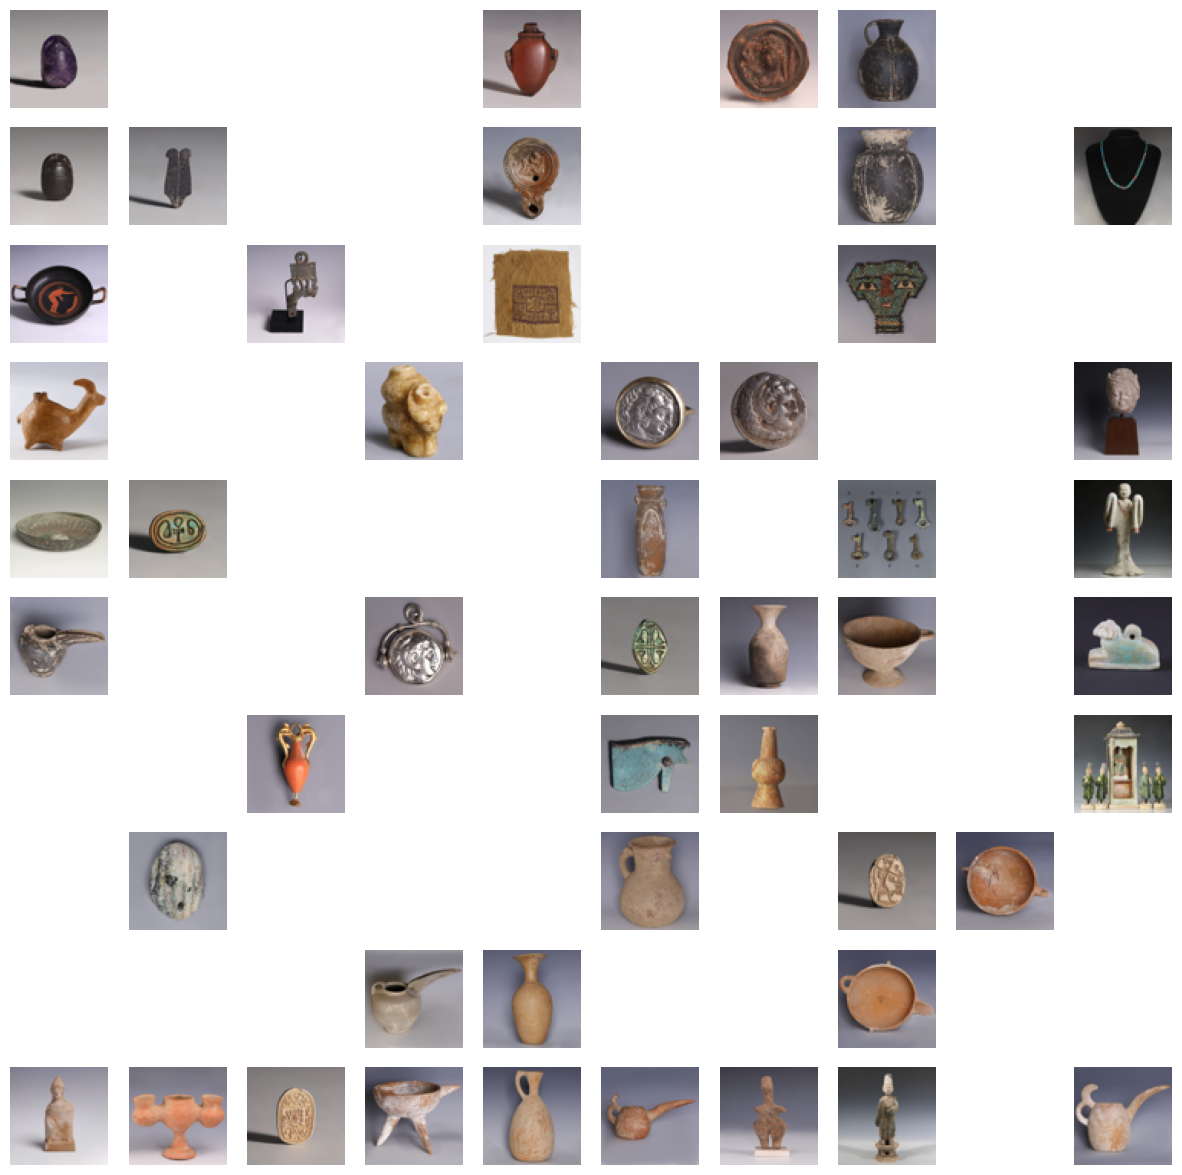

In [29]:
image_paths = [os.path.join("Image_Group_Test", file) for file in os.listdir("Image_Group_Test")]
visualize_som(loaded_som, data, image_paths)